# 🔍 Luminância v3 — Correções do Professor
**Correção 1:** PCA invariante à base (`_pca_distribution_features`)  
**Correção 2:** Data augmentation no treino (robustez a recompressão)  
**Correção 3:** Calibração isotônica + limiar ótimo por F1  
**Modelo:** XGBoost  
**Output:** `svm_luminance.pkl` + `scaler_luminance.pkl` + `threshold.json`

---
## Bloco 1 — Setup

In [2]:
import cv2
import numpy as np
import joblib
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import sobel
from io import BytesIO
from PIL import Image, ImageFilter, ImageEnhance, ImageFile
from concurrent.futures import ThreadPoolExecutor
import warnings
import time

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)
from xgboost import XGBClassifier

print('✅ Imports OK')

✅ Imports OK


In [3]:
# ─── CONFIGURAÇÕES ───────────────────────────────────────────────────────────
DATASET_ROOT = Path('./archive')
OUTPUT_DIR   = Path('./modelos/Luminescencia')
CACHE_DIR    = Path('./cache_lum_v3')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Três splits separados — correção 1 do professor
TRAIN_REAL = DATASET_ROOT / 'train' / 'real'
TRAIN_FAKE = DATASET_ROOT / 'train' / 'fake'
VAL_REAL   = DATASET_ROOT / 'val'   / 'real'   # para calibração e early stopping
VAL_FAKE   = DATASET_ROOT / 'val'   / 'fake'
TEST_REAL  = DATASET_ROOT / 'test'  / 'real'   # nunca tocar até avaliação final
TEST_FAKE  = DATASET_ROOT / 'test'  / 'fake'

RESIZE_TO  = (256, 256)
GRID       = 4
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

print('✅ Configurações OK')
print(f'   Output : {OUTPUT_DIR.resolve()}')
print(f'   Cache  : {CACHE_DIR.resolve()}')
print()

# Verificar se os splits existem
for name, path in [('train/real', TRAIN_REAL), ('train/fake', TRAIN_FAKE),
                   ('val/real',   VAL_REAL),   ('val/fake',   VAL_FAKE),
                   ('test/real',  TEST_REAL),  ('test/fake',  TEST_FAKE)]:
    exists = path.exists()
    count  = len([p for p in path.rglob('*') if p.suffix.lower() in EXTENSIONS]) if exists else 0
    status = '✅' if exists and count > 0 else '❌'
    print(f'   {status} {name:<15}: {count:,} imagens')

✅ Configurações OK
   Output : /home/gustavom/Área de trabalho/tcc/Xiz9/modelos_treinamento/modelos/Luminescencia
   Cache  : /home/gustavom/Área de trabalho/tcc/Xiz9/modelos_treinamento/cache_lum_v3

   ✅ train/real     : 20,400 imagens
   ✅ train/fake     : 20,400 imagens
   ✅ val/real       : 3,600 imagens
   ✅ val/fake       : 3,600 imagens
   ✅ test/real      : 6,000 imagens
   ✅ test/fake      : 6,000 imagens


---
## Bloco 2 — Funções de Features
> **Correção 1:** `_pca_distribution_features` — features invariantes à base do PCA

In [4]:
def _pca_distribution_features(eig: np.ndarray) -> list:
    """
    Features invariantes à base do PCA.
    Descrevem a DISTRIBUIÇÃO dos autovalores, não sua direção.
    Isso torna as features comparáveis entre imagens diferentes.
    
    Retorna 6 features:
    - eigen_entropy : entropia da distribuição de autovalores
    - top5_ratio    : razão entre os 5 maiores e 5 menores autovalores
    - n_50          : número de componentes para 50% da variância
    - n_90          : número de componentes para 90% da variância
    - n_95          : número de componentes para 95% da variância
    - slope         : decaimento espectral (slope do log-log)
    """
    eig_sorted    = np.sort(eig)[::-1]
    norm_eig      = eig_sorted / (eig_sorted.sum() + 1e-12)
    eigen_entropy = float(-np.sum(norm_eig * np.log(norm_eig + 1e-12)))
    top5_ratio    = float(eig_sorted[:5].sum() / (eig_sorted[-5:].sum() + 1e-12))
    cumsum        = np.cumsum(norm_eig)
    n_50          = int(np.searchsorted(cumsum, 0.50) + 1)
    n_90          = int(np.searchsorted(cumsum, 0.90) + 1)
    n_95          = int(np.searchsorted(cumsum, 0.95) + 1)
    k             = np.arange(1, len(eig_sorted) + 1)
    slope         = float(np.polyfit(np.log(k), np.log(eig_sorted + 1e-12), 1)[0])
    return [eigen_entropy, top5_ratio, n_50, n_90, n_95, slope]


def extract_luminance_features_v3(image_bytes: bytes):
    """
    Extrai ~72 features de luminância (v3):
    - PCA invariante     :  6 features (substituiu as 11 da v2)
    - Stats de gradiente :  5 features
    - FFT                :  5 features
    - HOG direções       :  8 features
    - Coerência          :  2 features
    - Normalização local :  3 features
    - Blocos 4x4         : 48 features
    Total: 77 features
    """
    try:
        img_array = np.frombuffer(image_bytes, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        if img is None:
            return None

        # ── Luminância ───────────────────────────────────────────────────────
        img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)
        img_r      = cv2.resize(img_rgb, RESIZE_TO)
        luminancia = (0.299 * img_r[:,:,0] +
                      0.587 * img_r[:,:,1] +
                      0.114 * img_r[:,:,2])

        # ── Gradientes Sobel ─────────────────────────────────────────────────
        grad_x    = sobel(luminancia, axis=1)
        grad_y    = sobel(luminancia, axis=0)
        magnitude = np.sqrt(grad_x**2 + grad_y**2)
        direcao   = np.arctan2(grad_y, grad_x)

        # ── 1. PCA invariante (6 features) ───────────────────────────────────
        # Correção do professor: usar autovalores, não explained_variance_ratio
        n   = min(30, min(magnitude.shape))
        pca = PCA(n_components=n, svd_solver='randomized', random_state=42)
        pca.fit(magnitude)
        eig = pca.explained_variance_

        pca_feats = _pca_distribution_features(eig) + [
            float(np.std(direcao)),
            float(np.mean(magnitude)),
            float(np.std(magnitude)),
            float(np.percentile(magnitude, 90)),
            float(np.mean(magnitude) / (np.std(magnitude) + 1e-10)),
        ]

        # ── 2. FFT da magnitude do gradiente (5 features) ────────────────────
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft2(magnitude)))
        h, w    = fft_mag.shape
        cy, cx  = h // 2, w // 2
        Y, X    = np.ogrid[:h, :w]
        dist    = np.sqrt((X - cx)**2 + (Y - cy)**2)
        md      = np.sqrt(cx**2 + cy**2)
        e_low   = float(np.sum(fft_mag[dist <= md * 0.1]**2))
        e_mid   = float(np.sum(fft_mag[(dist > md * 0.1) & (dist <= md * 0.4)]**2))
        e_high  = float(np.sum(fft_mag[dist > md * 0.4]**2))
        e_tot   = e_low + e_mid + e_high + 1e-12
        fft_feats = [
            e_low  / e_tot,
            e_mid  / e_tot,
            e_high / e_tot,
            e_high / (e_low + 1e-12),
            float(np.std(np.log1p(fft_mag))),
        ]

        # ── 3. Histograma de direções HOG (8 features) ───────────────────────
        hist_dir, _ = np.histogram(direcao, bins=8, range=(-np.pi, np.pi))
        hist_dir    = hist_dir / (hist_dir.sum() + 1e-10)
        hog_feats   = hist_dir.tolist()

        # ── 4. Coerência local do gradiente (2 features) ─────────────────────
        coer_v     = float(np.mean(np.cos(direcao[:-1, :] - direcao[1:, :])))
        coer_h     = float(np.mean(np.cos(direcao[:, :-1] - direcao[:, 1:])))
        coer_feats = [coer_v, coer_h]

        # ── 5. Normalização local (3 features) ───────────────────────────────
        blur       = cv2.GaussianBlur(magnitude.astype(np.float32), (15, 15), 0)
        mag_norm   = magnitude / (blur.astype(np.float64) + 1e-6)
        norm_feats = [
            float(np.mean(mag_norm)),
            float(np.std(mag_norm)),
            float(np.percentile(mag_norm, 95)),
        ]

        # ── 6. Features por blocos 4x4 (48 features) ─────────────────────────
        bh, bw      = RESIZE_TO[0] // GRID, RESIZE_TO[1] // GRID
        block_feats = []
        for i in range(GRID):
            for j in range(GRID):
                bloco = magnitude[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
                block_feats.append(float(np.mean(bloco)))
                block_feats.append(float(np.std(bloco)))
                block_feats.append(float(np.percentile(bloco, 90)))

        # ── Concatenar e sanitizar ────────────────────────────────────────────
        all_feats = (pca_feats + fft_feats + hog_feats +
                     coer_feats + norm_feats + block_feats)
        result = np.array(all_feats, dtype=np.float32)
        result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
        return result

    except Exception:
        return None


# Teste rápido
test_files = [p for p in TRAIN_REAL.rglob('*') if p.suffix.lower() in EXTENSIONS]
sample = extract_luminance_features_v3(test_files[0].read_bytes())
print(f'✅ Features v3: {len(sample)} dimensões')
print(f'   NaN: {np.isnan(sample).sum()} | Inf: {np.isinf(sample).sum()}')

✅ Features v3: 77 dimensões
   NaN: 0 | Inf: 0


---
## Bloco 3 — Data Augmentation
> **Correção 2:** Robustez a recompressão JPEG, redimensionamento e blur

✅ Função de augmentation definida


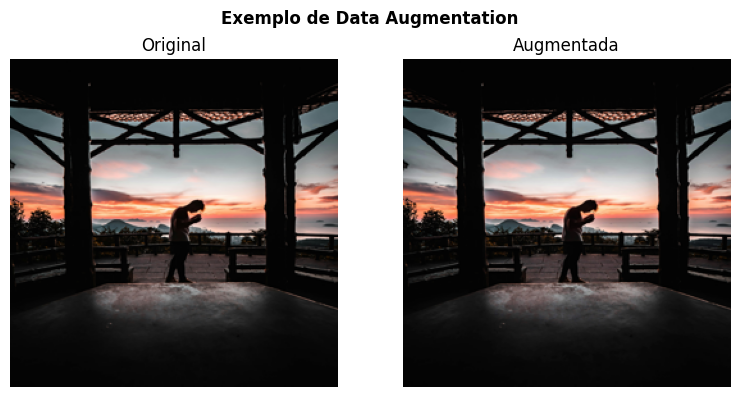

In [7]:
def augment_image_bytes(image_bytes: bytes) -> bytes:
    """
    Augmentation para robustez a recompressão e domain shift.
    Aplicar APENAS no treino — nunca na validação ou teste.
    
    Especialmente importante para Luminescência pois gradientes
    Sobel são sensíveis a borramento e recompressão JPEG.
    """
    img = Image.open(BytesIO(image_bytes)).convert('RGB')

    # Resize aleatório (simula diferentes resoluções)
    if random.random() < 0.5:
        scale = random.uniform(0.75, 1.25)
        img = img.resize(
            (int(img.width * scale), int(img.height * scale)),
            Image.LANCZOS
        )

    # Recompressão JPEG — crítico para gradientes Sobel
    if random.random() < 0.7:
        quality = random.randint(60, 95)
        buf = BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        img = Image.open(BytesIO(buf.getvalue())).convert('RGB')

    # Blur leve (simula desfoque de câmera ou screenshot)
    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(
            radius=random.uniform(0.3, 1.0)
        ))

    # Brilho e contraste
    if random.random() < 0.3:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))

    out = BytesIO()
    img.save(out, format='PNG')
    return out.getvalue()


print('✅ Função de augmentation definida')

# Teste visual do augmentation
raw_sample    = test_files[0].read_bytes()
aug_sample    = augment_image_bytes(raw_sample)
img_orig      = Image.open(BytesIO(raw_sample)).convert('RGB').resize(RESIZE_TO)
img_aug       = Image.open(BytesIO(aug_sample)).convert('RGB').resize(RESIZE_TO)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_orig); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_aug);  axes[1].set_title('Augmentada'); axes[1].axis('off')
plt.suptitle('Exemplo de Data Augmentation', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bloco 4 — Extração do Dataset
> Treino com augmentation | Validação e Teste sem augmentation

In [5]:
import numpy as np
from pathlib import Path

CACHE_DIR = Path('./cache_lum_v3')

for f in CACHE_DIR.glob('*.npy'):
    data = np.load(f)
    print(f'{f.name}: shape={data.shape}')

train_X.npy: shape=(81595, 77)
train_y.npy: shape=(81595,)
val_X.npy: shape=(7198, 77)
val_y.npy: shape=(7198,)
test_X.npy: shape=(11997, 77)
test_y.npy: shape=(11997,)


In [8]:
def list_images(folder: Path):
    return [p for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]


def process_single(args):
    fpath, label, augment = args
    results = []
    try:
        raw  = fpath.read_bytes()
        feat = extract_luminance_features_v3(raw)
        if feat is not None:
            results.append((feat, label))
        # Cópia aumentada — somente no treino
        if augment:
            feat_aug = extract_luminance_features_v3(augment_image_bytes(raw))
            if feat_aug is not None:
                results.append((feat_aug, label))
    except Exception:
        pass
    return results



def extract_split(real_folder, fake_folder, prefix,
                  augment=False, n_workers=8):
    cache_X = CACHE_DIR / f'{prefix}_X.npy'
    cache_y = CACHE_DIR / f'{prefix}_y.npy'

    if cache_X.exists() and cache_y.exists():
        print(f'📦 Carregando {prefix} do cache...')
        X, y = np.load(cache_X), np.load(cache_y)
        print(f'   ✅ {len(X):,} amostras')
        return X, y

    all_files = ([(f, 0, augment) for f in list_images(real_folder)] +
                 [(f, 1, augment) for f in list_images(fake_folder)])

    aug_str = ' + augmentation' if augment else ''
    n_orig  = len(all_files)
    n_est   = n_orig * 2 if augment else n_orig
    print(f'⚙️  Extraindo {prefix} ({n_orig:,} imagens{aug_str} → ~{n_est:,} amostras)...')

    X, y       = [], []
    start_time = time.time()
    eta_str    = 'calculando...'

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for i, results in enumerate(tqdm(
            executor.map(process_single, all_files),
            total=len(all_files),
            desc=prefix,
            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] ' + '{postfix}'
        ), 1):
            for feat, label in results:
                X.append(feat)
                y.append(label)

            # Atualizar estimativa a cada 50 imagens
            if i % 50 == 0:
                elapsed  = time.time() - start_time
                rate     = i / elapsed
                remaining = (n_orig - i) / rate
                mins, secs = divmod(int(remaining), 60)
                eta_str  = f'ETA: {mins}m{secs:02d}s ({rate:.1f} img/s)'
                print(f'\r   ⏱️  {eta_str}', end='', flush=True)

    print()  # nova linha após os updates
    elapsed_total = time.time() - start_time
    mins, secs = divmod(int(elapsed_total), 60)
    print(f'   ⏱️  Tempo total: {mins}m{secs:02d}s')

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int8)
    np.save(cache_X, X)
    np.save(cache_y, y)
    print(f'   ✅ {len(X):,} amostras salvas')
    return X, y


# Treino COM augmentation | Val e Test SEM augmentation
X_train, y_train = extract_split(TRAIN_REAL, TRAIN_FAKE, 'train', augment=True)
X_val,   y_val   = extract_split(VAL_REAL,   VAL_FAKE,   'val',   augment=False)
X_test,  y_test  = extract_split(TEST_REAL,  TEST_FAKE,  'test',  augment=False)

print(f'\n📐 Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'📊 Train — Real: {(y_train==0).sum():,} | Fake: {(y_train==1).sum():,}')
print(f'📊 Val   — Real: {(y_val==0).sum():,}   | Fake: {(y_val==1).sum():,}')
print(f'📊 Test  — Real: {(y_test==0).sum():,}  | Fake: {(y_test==1).sum():,}')

⚙️  Extraindo train (40,800 imagens + augmentation → ~81,600 amostras)...


train:   0%|          | 35/40800 [00:36<24:08:38] 

   ⏱️  ETA: 509m32s (1.3 img/s)

train:   0%|          | 99/40800 [01:05<5:41:33]  

   ⏱️  ETA: 448m50s (1.5 img/s)

...

   ⏱️  ETA: 0m04s (10.0 img/s)

test: 100%|█████████▉| 11996/12000 [19:56<00:00] 

   ⏱️  ETA: 0m00s (10.0 img/s)

test: 100%|██████████| 12000/12000 [19:56<00:00] 


   ⏱️  Tempo total: 19m56s
   ✅ 11,997 amostras salvas

📐 Train: (81595, 77) | Val: (7198, 77) | Test: (11997, 77)
📊 Train — Real: 40,795 | Fake: 40,800
📊 Val   — Real: 3,598   | Fake: 3,600
📊 Test  — Real: 5,997  | Fake: 6,000


---
## Bloco 5 — Normalização

In [6]:
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'✅ Scaler aplicado')
print(f'   NaN — train: {np.isnan(X_train_s).sum()} | val: {np.isnan(X_val_s).sum()} | test: {np.isnan(X_test_s).sum()}')

NameError: name 'X_train' is not defined

---
## Bloco 6 — Treinamento XGBoost
> Early stopping usando `val` — não o `test`

In [11]:
n_real = (y_train == 0).sum()
n_fake = (y_train == 1).sum()
scale_pos_weight = n_real / n_fake
print(f'⚖️  scale_pos_weight: {scale_pos_weight:.2f}')

model = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

print('🚀 Treinando XGBoost (early stopping no val)...')
model.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],   # ← val, não test
    verbose=False
)

# Avaliação no test (primeira vez que o test é visto)
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print(f'\n📊 Resultados no TEST (nunca visto no treino):')
print(f'   Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'   F1       : {f1_score(y_test, y_pred):.4f}')
print(f'   AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}')
print(f'   Brier    : {brier_score_loss(y_test, y_proba):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Real", "IA"])}')

⚖️  scale_pos_weight: 1.00
🚀 Treinando XGBoost (early stopping no val)...

📊 Resultados no TEST (nunca visto no treino):
   Accuracy : 0.8385
   F1       : 0.8416
   AUC-ROC  : 0.9180
   Brier    : 0.1146

              precision    recall  f1-score   support

        Real       0.85      0.82      0.84      5997
          IA       0.83      0.86      0.84      6000

    accuracy                           0.84     11997
   macro avg       0.84      0.84      0.84     11997
weighted avg       0.84      0.84      0.84     11997



---
## Bloco 7 — Calibração + Limiar Ótimo
> **Correção 3:** Calibração isotônica no `val` + limiar F1 ótimo

In [15]:
from sklearn.isotonic import IsotonicRegression

print('⚙️  Calibrando probabilidades (isotonic)...')

# Probabilidades brutas do modelo original
y_proba_val_raw  = model.predict_proba(X_val_s)[:, 1]
y_proba_test_raw = model.predict_proba(X_test_s)[:, 1]

# Calibração isotônica manual no val
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(y_proba_val_raw, y_val)

# Aplicar calibração no test
y_proba_cal  = iso.predict(y_proba_test_raw)
brier_before = brier_score_loss(y_test, y_proba_test_raw)
brier_after  = brier_score_loss(y_test, y_proba_cal)
print(f'   Brier antes : {brier_before:.4f}')
print(f'   Brier depois: {brier_after:.4f} ({"✅ melhorou" if brier_after < brier_before else "⚠️ piorou"})')

# Limiar ótimo por F1 no val
print('\n⚙️  Calculando limiar ótimo por F1 (no val)...')
y_proba_val_cal       = iso.predict(y_proba_val_raw)
prec, rec, thresholds = precision_recall_curve(y_val, y_proba_val_cal)
f1_scores             = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_idx              = np.argmax(f1_scores)
best_thr              = float(thresholds[best_idx])

print(f'   Limiar padrão (0.50): F1 = {f1_score(y_test, (y_proba_cal >= 0.50).astype(int)):.4f}')
print(f'   Limiar ótimo  ({best_thr:.2f}): F1 = {f1_score(y_test, (y_proba_cal >= best_thr).astype(int)):.4f}')

y_pred_final = (y_proba_cal >= best_thr).astype(int)
print(f'\n📊 Resultado FINAL (calibrado + limiar ótimo):')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'   F1       : {f1_score(y_test, y_pred_final):.4f}')
print(f'   AUC-ROC  : {roc_auc_score(y_test, y_proba_cal):.4f}')
print(f'\n{classification_report(y_test, y_pred_final, target_names=["Real", "IA"])}')

⚙️  Calibrando probabilidades (isotonic)...
   Brier antes : 0.1146
   Brier depois: 0.1150 (⚠️ piorou)

⚙️  Calculando limiar ótimo por F1 (no val)...
   Limiar padrão (0.50): F1 = 0.8404
   Limiar ótimo  (0.44): F1 = 0.8419

📊 Resultado FINAL (calibrado + limiar ótimo):
   Accuracy : 0.8320
   F1       : 0.8419
   AUC-ROC  : 0.9173

              precision    recall  f1-score   support

        Real       0.88      0.77      0.82      5997
          IA       0.79      0.89      0.84      6000

    accuracy                           0.83     11997
   macro avg       0.84      0.83      0.83     11997
weighted avg       0.84      0.83      0.83     11997



---
## Bloco 8 — Análise de Eficiência e Viés

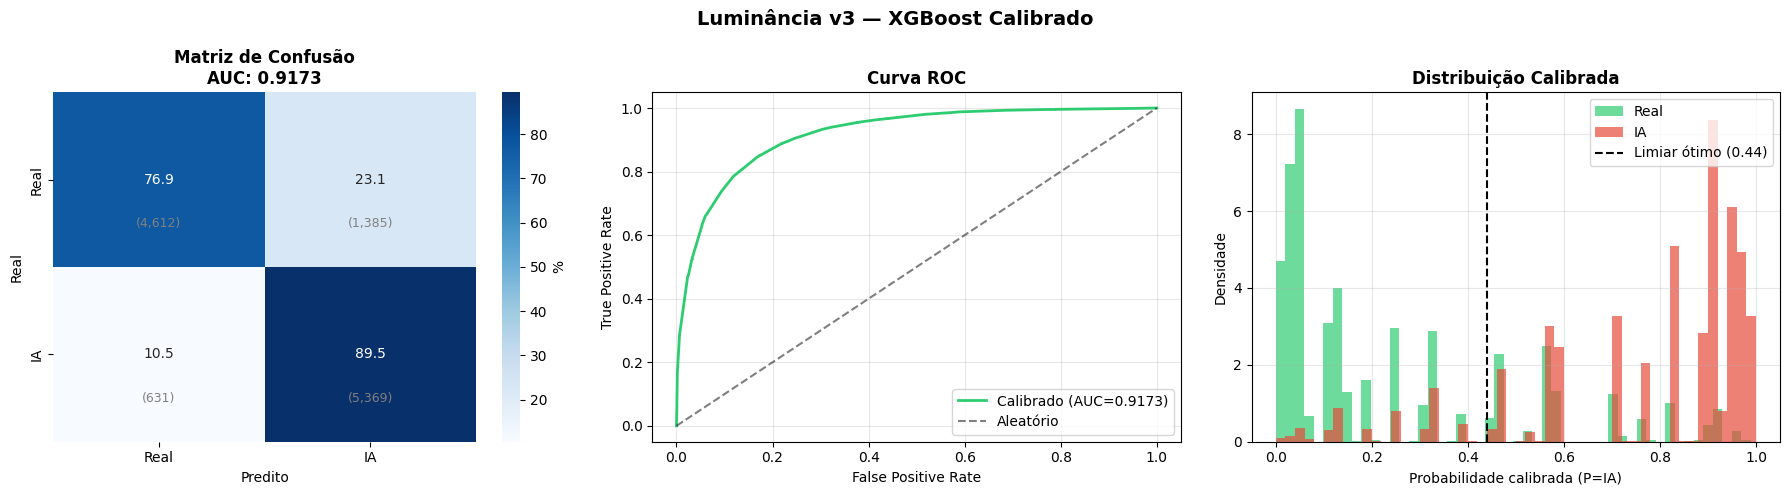


🔬 Análise de viés:
   Falsos Positivos (Real → IA): 1,385 (23.1%)
   Falsos Negativos (IA → Real): 631 (10.5%)
   Zona de incerteza (35%-65%): 16.1%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
auc = roc_auc_score(y_test, y_proba_cal)

# Matriz de confusão
cm     = confusion_matrix(y_test, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.75, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=9, color='gray')
axes[0].set_title(f'Matriz de Confusão\nAUC: {auc:.4f}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_cal)
axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'Calibrado (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Distribuição de probabilidades calibradas
axes[2].hist(y_proba_cal[y_test==0], bins=50, alpha=0.7,
             color='#2ecc71', label='Real', density=True)
axes[2].hist(y_proba_cal[y_test==1], bins=50, alpha=0.7,
             color='#e74c3c', label='IA', density=True)
axes[2].axvline(best_thr, color='black', linestyle='--',
                label=f'Limiar ótimo ({best_thr:.2f})')
axes[2].set_xlabel('Probabilidade calibrada (P=IA)')
axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição Calibrada', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Luminância v3 — XGBoost Calibrado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'resultados_lum_v3.png', dpi=120, bbox_inches='tight')
plt.show()

# Análise de viés
fn = cm[0, 1]
fp = cm[1, 0]
uncertain = ((y_proba_cal > 0.35) & (y_proba_cal < 0.65)).mean() * 100
print(f'\n🔬 Análise de viés:')
print(f'   Falsos Positivos (Real → IA): {fn:,} ({fn/cm[0].sum()*100:.1f}%)')
print(f'   Falsos Negativos (IA → Real): {fp:,} ({fp/cm[1].sum()*100:.1f}%)')
print(f'   Zona de incerteza (35%-65%): {uncertain:.1f}%')

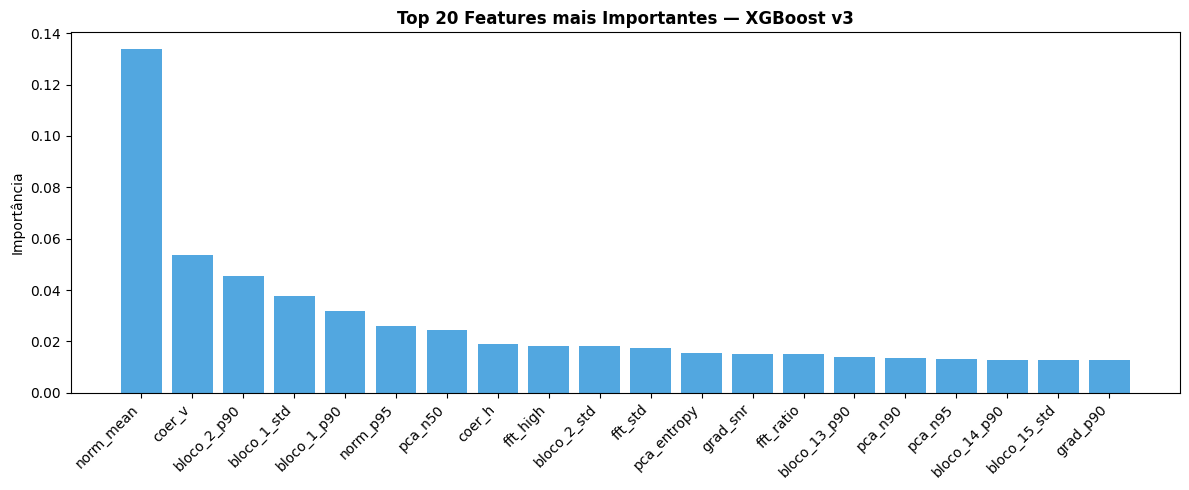

In [17]:
# Importância das features
feature_names = (
    ['pca_entropy', 'pca_top5ratio', 'pca_n50', 'pca_n90', 'pca_n95', 'pca_slope'] +
    ['grad_std_dir', 'grad_mean_mag', 'grad_std_mag', 'grad_p90', 'grad_snr'] +
    ['fft_low', 'fft_mid', 'fft_high', 'fft_ratio', 'fft_std'] +
    [f'hog_{i}' for i in range(8)] +
    ['coer_v', 'coer_h'] +
    ['norm_mean', 'norm_std', 'norm_p95'] +
    [f'bloco_{i//3}_{["mean","std","p90"][i%3]}' for i in range(GRID*GRID*3)]
)

importances = model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.85)
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Features mais Importantes — XGBoost v3', fontweight='bold')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance_v3.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Bloco 9 — Salvar Modelos

In [18]:
joblib.dump(model,  OUTPUT_DIR / 'svm_luminance.pkl')
joblib.dump(iso,    OUTPUT_DIR / 'calibrator_luminance.pkl')
joblib.dump(scaler, OUTPUT_DIR / 'scaler_luminance.pkl')

with open(OUTPUT_DIR / 'threshold.json', 'w') as f:
    json.dump({'threshold': best_thr}, f, indent=2)

print('💾 Modelos salvos:')
print(f'   {OUTPUT_DIR / "svm_luminance.pkl"}          ← modelo XGBoost')
print(f'   {OUTPUT_DIR / "calibrator_luminance.pkl"}   ← calibrador isotônico')
print(f'   {OUTPUT_DIR / "scaler_luminance.pkl"}       ← scaler')
print(f'   {OUTPUT_DIR / "threshold.json"}             ← limiar ótimo: {best_thr:.4f}')
print('\n✅ Drop-in replacement pronto!')
print('   Lembrar de atualizar _extract_luminance_features no bronze_service.py')

💾 Modelos salvos:
   modelos/Luminescencia/svm_luminance.pkl          ← modelo XGBoost
   modelos/Luminescencia/calibrator_luminance.pkl   ← calibrador isotônico
   modelos/Luminescencia/scaler_luminance.pkl       ← scaler
   modelos/Luminescencia/threshold.json             ← limiar ótimo: 0.4400

✅ Drop-in replacement pronto!
   Lembrar de atualizar _extract_luminance_features no bronze_service.py


In [21]:
import joblib
import numpy as np

scaler     = joblib.load('modelos/Luminescencia/scaler_luminance.pkl')
model      = joblib.load('modelos/Luminescencia/svm_luminance.pkl')
calibrator = joblib.load('modelos/Luminescencia/calibrator_luminance.pkl')

# Testar com uma imagem real conhecida
from pathlib import Path
real_img = list(Path('archive/test/real').rglob('*.jpg'))[0]
feat = extract_luminance_features_v3(real_img.read_bytes())
feat_s = scaler.transform([feat])
proba = model.predict_proba(feat_s)[0]
print(f'proba[0]={proba[0]:.3f} | proba[1]={proba[1]:.3f}')
print(f'Classes do modelo: {model.classes_}')

proba[0]=0.608 | proba[1]=0.392
Classes do modelo: [0 1]


In [22]:
proba_cal = calibrator.predict([proba[1]])[0]
print(f'Antes da calibração : prob_ia = {proba[1]:.3f}')
print(f'Depois da calibração: prob_ia = {proba_cal:.3f}')

Antes da calibração : prob_ia = 0.392
Depois da calibração: prob_ia = 0.367


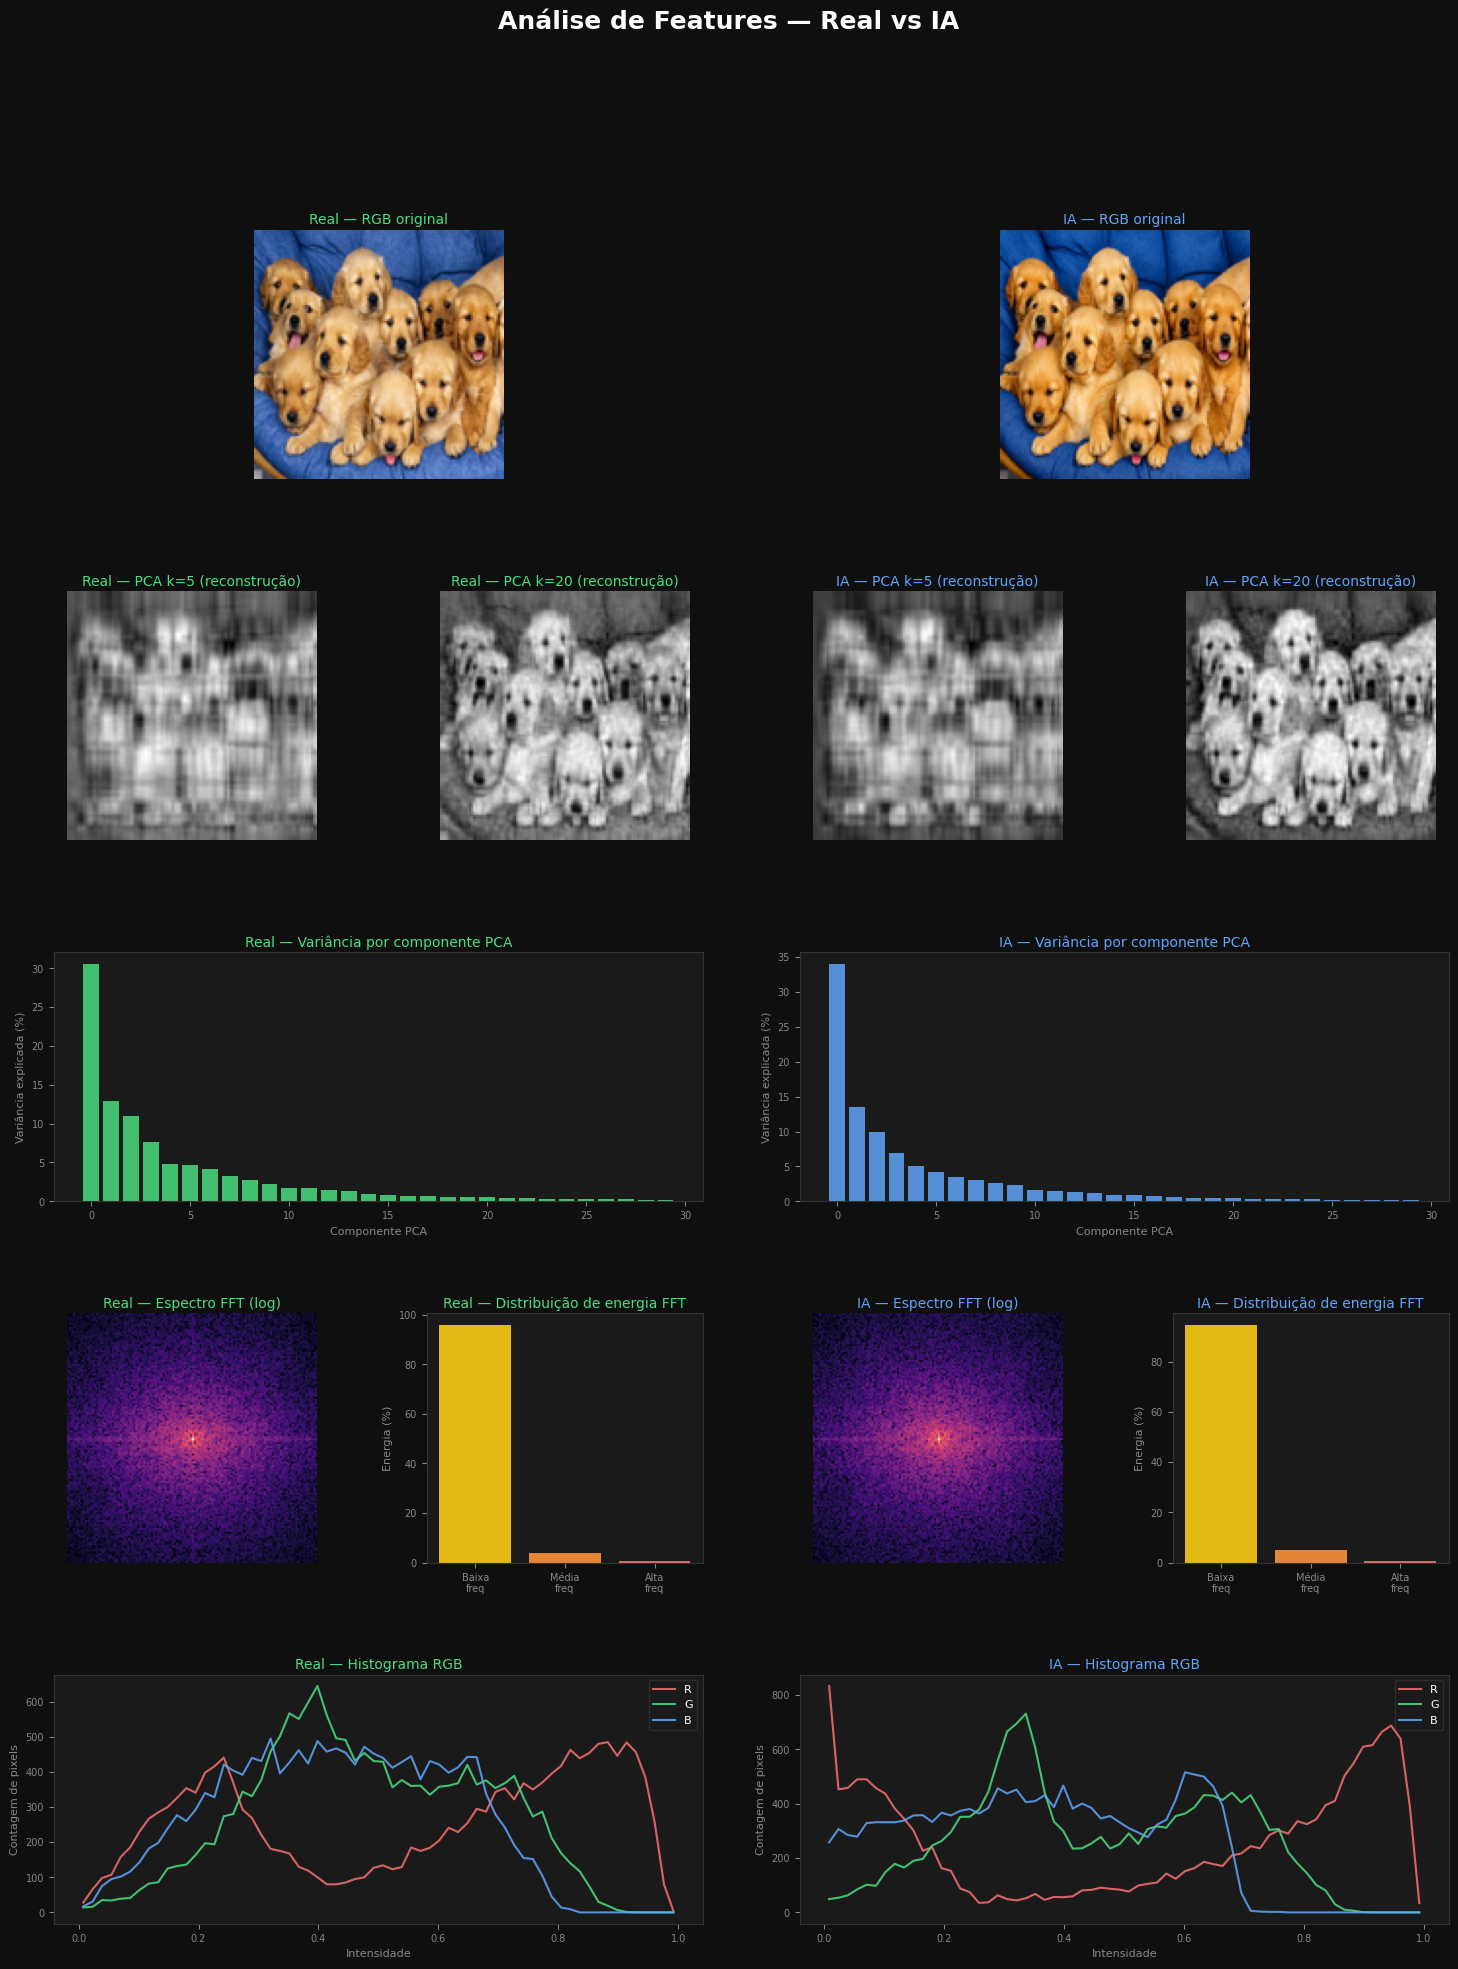

Salvo: analise_features.png


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.decomposition import PCA

# ── Configurações ──────────────────────────────────────────────
REAL_PATH = "foto_real.jpg"
AI_PATH   = "foto_ia.jpg"
RESIZE_TO = (128, 128)
N_COMPONENTS = 30
# ──────────────────────────────────────────────────────────────

def load_image(path):
    img_rgb  = Image.open(path).convert('RGB').resize(RESIZE_TO)
    img_gray = img_rgb.convert('L')
    arr_rgb  = np.array(img_rgb,  dtype=np.float64) / 255.0
    arr_gray = np.array(img_gray, dtype=np.float64) / 255.0
    return img_rgb, arr_rgb, arr_gray

def pca_reconstruction(arr_gray, k):
    n   = min(N_COMPONENTS, min(arr_gray.shape))
    pca = PCA(n_components=n, svd_solver='randomized', random_state=42)
    scores = pca.fit_transform(arr_gray)
    sk = np.zeros_like(scores)
    sk[:, :k] = scores[:, :k]
    return pca.inverse_transform(sk), pca.explained_variance_ratio_

def fft_spectrum(arr_gray):
    fft     = np.fft.fft2(arr_gray)
    fft_mag = np.abs(np.fft.fftshift(fft))
    return np.log1p(fft_mag)

def fft_energy_bars(arr_gray):
    fft     = np.fft.fft2(arr_gray)
    fft_mag = np.abs(np.fft.fftshift(fft))
    h, w    = fft_mag.shape
    cy, cx  = h // 2, w // 2
    Y, X    = np.ogrid[:h, :w]
    dist    = np.sqrt((X - cx)**2 + (Y - cy)**2)
    max_d   = np.sqrt(cx**2 + cy**2)

    e_low   = float(np.sum(fft_mag[dist <= max_d * 0.1]**2))
    e_mid   = float(np.sum(fft_mag[(dist > max_d*0.1) & (dist <= max_d*0.4)]**2))
    e_high  = float(np.sum(fft_mag[dist > max_d * 0.4]**2))
    total   = e_low + e_mid + e_high + 1e-12
    return [e_low/total, e_mid/total, e_high/total]

def color_histograms(arr_rgb):
    histograms = []
    for c in range(3):
        hist, bins = np.histogram(arr_rgb[:,:,c].ravel(), bins=64, range=(0,1))
        histograms.append((hist, bins))
    return histograms

def compare_full(real_path, ai_path):
    img_r, arr_r, gray_r = load_image(real_path)
    img_a, arr_a, gray_a = load_image(ai_path)

    # PCA
    rec_r5,  evr_r = pca_reconstruction(gray_r, 5)
    rec_a5,  evr_a = pca_reconstruction(gray_a, 5)
    rec_r20, _     = pca_reconstruction(gray_r, 20)
    rec_a20, _     = pca_reconstruction(gray_a, 20)

    # FFT
    fft_r = fft_spectrum(gray_r)
    fft_a = fft_spectrum(gray_a)
    bars_r = fft_energy_bars(gray_r)
    bars_a = fft_energy_bars(gray_a)

    # Histogramas RGB
    hist_r = color_histograms(arr_r)
    hist_a = color_histograms(arr_a)

    # ── Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 22), facecolor='#0f0f0f')
    fig.suptitle("Análise de Features — Real vs IA", fontsize=18,
                 fontweight='bold', color='white', y=0.98)

    gs = gridspec.GridSpec(5, 4, figure=fig, hspace=0.45, wspace=0.35)

    COR_R = '#4ade80'   # verde
    COR_A = '#60a5fa'   # azul

    def ax(row, col, colspan=1):
        return fig.add_subplot(gs[row, col:col+colspan])

    def title(a, t, cor):
        a.set_title(t, color=cor, fontsize=10, pad=4)

    def style(a):
        a.set_facecolor('#1a1a1a')
        a.tick_params(colors='#888', labelsize=7)
        for sp in a.spines.values():
            sp.set_edgecolor('#333')

    # ── Linha 0: imagens originais ────────────────────────────
    a = ax(0, 0, 2)
    a.imshow(np.array(img_r))
    title(a, "Real — RGB original", COR_R); a.axis('off')

    a = ax(0, 2, 2)
    a.imshow(np.array(img_a))
    title(a, "IA — RGB original", COR_A); a.axis('off')

    # ── Linha 1: PCA reconstrução k=5 e k=20 ─────────────────
    for col, rec5, rec20, evr, cor, label in [
        (0, rec_r5, rec_r20, evr_r, COR_R, "Real"),
        (2, rec_a5, rec_a20, evr_a, COR_A, "IA"),
    ]:
        a = ax(1, col)
        a.imshow(np.clip(rec5, 0, 1), cmap='gray')
        title(a, f"{label} — PCA k=5 (reconstrução)", cor); a.axis('off')

        a = ax(1, col+1)
        a.imshow(np.clip(rec20, 0, 1), cmap='gray')
        title(a, f"{label} — PCA k=20 (reconstrução)", cor); a.axis('off')

    # ── Linha 2: Variância explicada PCA ─────────────────────
    for col, evr, cor, label in [
        (0, evr_r, COR_R, "Real"), (2, evr_a, COR_A, "IA")
    ]:
        a = ax(2, col, 2); style(a)
        n = len(evr)
        a.bar(range(n), evr * 100, color=cor, alpha=0.85, width=0.8)
        a.set_xlabel("Componente PCA", color='#888', fontsize=8)
        a.set_ylabel("Variância explicada (%)", color='#888', fontsize=8)
        title(a, f"{label} — Variância por componente PCA", cor)

    # ── Linha 3: Espectro FFT ─────────────────────────────────
    for col, fft, bars, cor, label in [
        (0, fft_r, bars_r, COR_R, "Real"),
        (2, fft_a, bars_a, COR_A, "IA"),
    ]:
        a = ax(3, col)
        a.imshow(fft, cmap='magma'); a.axis('off')
        title(a, f"{label} — Espectro FFT (log)", cor)

        a = ax(3, col+1); style(a)
        cores_bar = ['#facc15', '#fb923c', '#f87171']
        a.bar(['Baixa\nfreq', 'Média\nfreq', 'Alta\nfreq'],
              [b*100 for b in bars], color=cores_bar, alpha=0.9)
        a.set_ylabel("Energia (%)", color='#888', fontsize=8)
        title(a, f"{label} — Distribuição de energia FFT", cor)

    # ── Linha 4: Histogramas RGB ──────────────────────────────
    canal_cores = ['#f87171', '#4ade80', '#60a5fa']  # R, G, B
    canal_nomes = ['R', 'G', 'B']

    for col_offset, hist_data, cor, label in [
        (0, hist_r, COR_R, "Real"),
        (2, hist_a, COR_A, "IA"),
    ]:
        a = ax(4, col_offset, 2); style(a)
        for (h, bins), cc, cn in zip(hist_data, canal_cores, canal_nomes):
            centers = (bins[:-1] + bins[1:]) / 2
            a.plot(centers, h, color=cc, alpha=0.85, linewidth=1.5, label=cn)
        a.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white',
                 edgecolor='#333')
        a.set_xlabel("Intensidade", color='#888', fontsize=8)
        a.set_ylabel("Contagem de pixels", color='#888', fontsize=8)
        title(a, f"{label} — Histograma RGB", cor)

    plt.savefig("analise_features.png", dpi=150, bbox_inches='tight',
                facecolor='#0f0f0f')
    plt.show()
    print("Salvo: analise_features.png")



REAL_PATH = "descubra-agora-5-cuidados-que-se-deve-ter-com-os-filhotes-de-cachorro-3.jpg"
AI_PATH   = "ChatGPT Image 26 de mai. de 2026, 13_53_33.png"
# ────────────────────────────────────────

compare_full(REAL_PATH, AI_PATH)

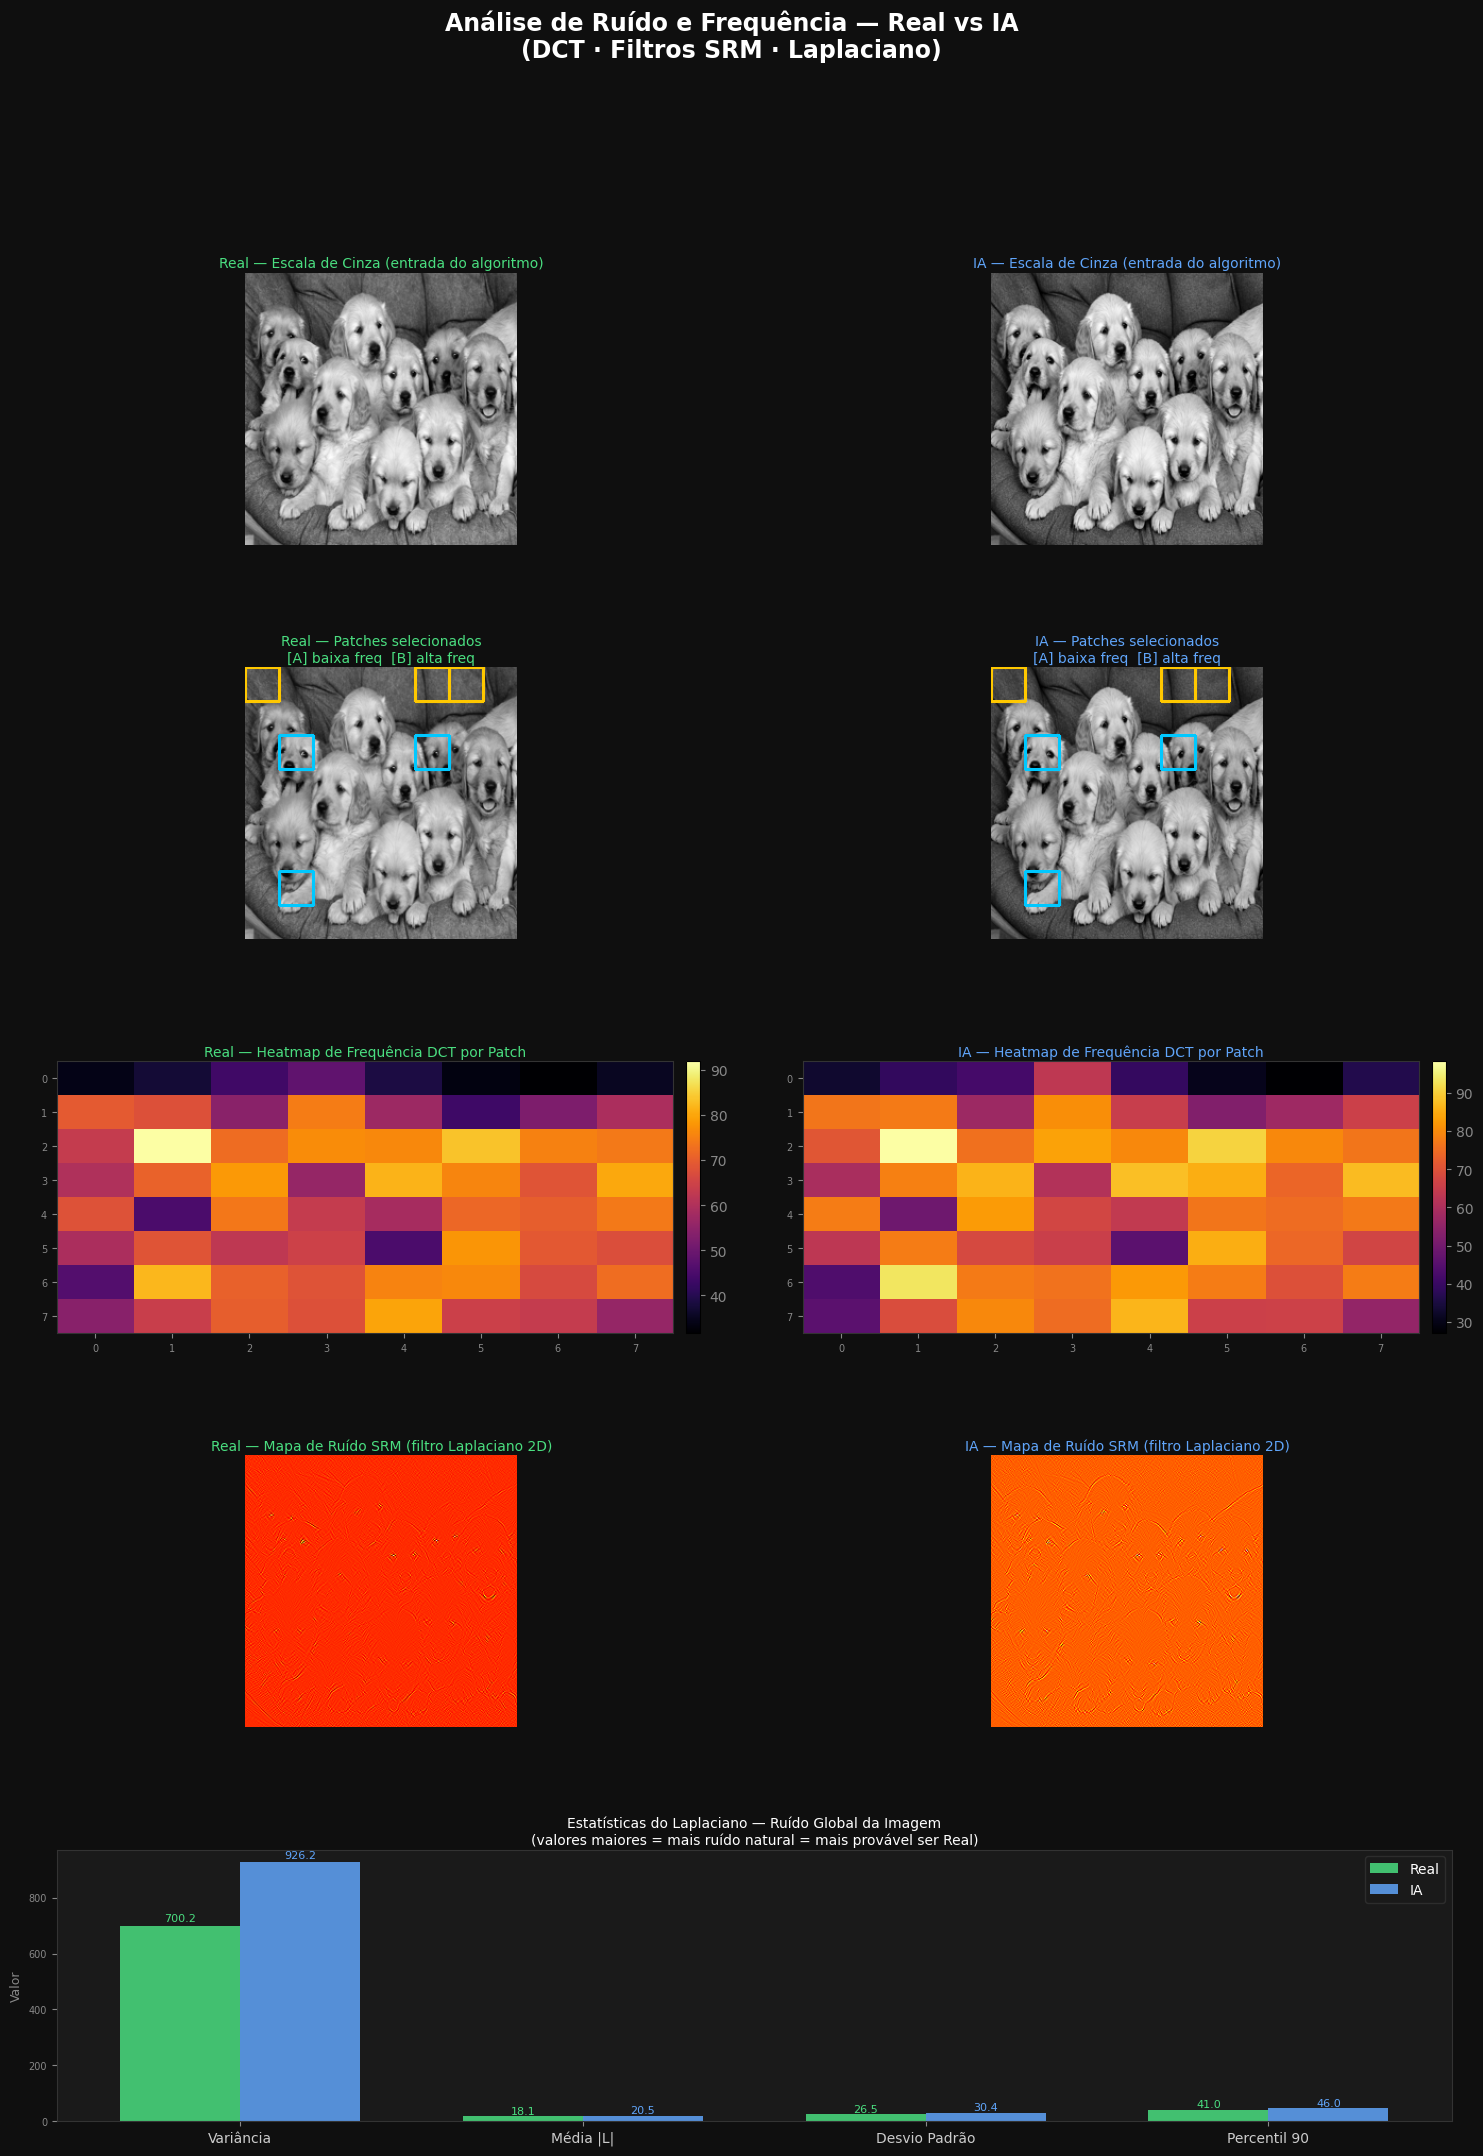

Salvo: analise_ruido.png
